#AI24: "Биржевая и внебиржевая торговля, оптимизация портфеля" (team 31)

# Чекпоинт №5 - Эксперименты с нелинейными моделями.


### Использование AUTO-ML

In [1]:
!pip install yfinance h2o

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import h2o
from h2o.automl import H2OAutoML
from datetime import datetime, timedelta

In [3]:
# h2o инициализация
h2o.init(max_mem_size="4G", nthreads=-1)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.26" 2025-01-21; OpenJDK Runtime Environment (build 11.0.26+4-post-Ubuntu-1ubuntu122.04); OpenJDK 64-Bit Server VM (build 11.0.26+4-post-Ubuntu-1ubuntu122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.11/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpo5rtn9js
  JVM stdout: /tmp/tmpo5rtn9js/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpo5rtn9js/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.6
H2O_cluster_version_age:,4 months and 12 days
H2O_cluster_name:,H2O_from_python_unknownUser_lg1vng
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,4 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [4]:
# Снова выбираем тикеры из разных секторов для тестирования
tickers = ['AAPL', 'JNJ', 'XOM', 'JPM', 'WMT']

data = yf.download(tickers, period='max')['Close']

# Ежедневные доходности
returns = data.pct_change().dropna()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  5 of 5 completed


In [7]:
# Дополнение данных расшиненным набором признаков

def compute_RSI(series, period=14):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.rolling(window=period).mean()
    roll_down = down.rolling(window=period).mean()
    RS = roll_up / roll_down
    RSI = 100.0 - (100.0 / (1.0 + RS))
    return RSI

def compute_MACD(series, fast=12, slow=26, signal=9):
    exp1 = series.ewm(span=fast, adjust=False).mean()
    exp2 = series.ewm(span=slow, adjust=False).mean()
    macd = exp1 - exp2
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

[RSI (Relative Strength Index)
](https://en.wikipedia.org/wiki/Relative_strength_index)

[MACD](https://en.wikipedia.org/wiki/MACD)

In [8]:
def create_features_extended(series, n_lags=5):
    df = pd.DataFrame(series.copy())
    df.rename(columns={series.name: 'value'}, inplace=True)

    # Лаги
    for lag in range(1, n_lags+1):
        df[f'lag_{lag}'] = df['value'].shift(lag)

    # Скольз. средние
    df['ma_5'] = df['value'].rolling(window=5).mean()
    df['ma_10'] = df['value'].rolling(window=10).mean()
    df['ma_20'] = df['value'].rolling(window=20).mean()

    # Волатильность: стандартное отклонение за 5 дней
    df['vol_5'] = df['value'].rolling(window=5).std()

    # RSI (период 14)
    df['RSI_14'] = compute_RSI(df['value'], period=14)

    # MACD и его сигнальная линия
    macd, macd_signal = compute_MACD(df['value'])
    df['MACD'] = macd
    df['MACD_signal'] = macd_signal

    # Bollinger Bands (20-дневная SMA и ±2 стандартных отклонения)
    df['bollinger_mid'] = df['value'].rolling(window=20).mean()
    df['bollinger_std'] = df['value'].rolling(window=20).std()
    df['bollinger_upper'] = df['bollinger_mid'] + 2 * df['bollinger_std']
    df['bollinger_lower'] = df['bollinger_mid'] - 2 * df['bollinger_std']

    df.dropna(inplace=True)
    return df

In [10]:
# Датасет [на текущий момент, целевая переменная — значение на следующий период (сдвиг на target_shift)]

def prepare_dataset_extended(series, target_shift=1, n_lags=5):
    df = create_features_extended(series, n_lags)
    df['target'] = df['value'].shift(-target_shift)
    df.dropna(inplace=True)
    return df

In [11]:
def train_test_split_time(df, test_size=0.2):
    split_index = int(len(df) * (1 - test_size))
    train = df.iloc[:split_index]
    test = df.iloc[split_index:]
    return train, test

Тут разделим задачи (прогноз цены и прогноз доходности)

In [12]:
def prepare_data_for_ticker(series, target_shift=1, n_lags=5, task='price'):
    if task == 'return':
        series = series.pct_change().dropna()
        series.name = 'return'
    df = prepare_dataset_extended(series, target_shift, n_lags)
    train_df, test_df = train_test_split_time(df, test_size=0.2)
    return train_df, test_df

data_dict = {}
for ticker in tickers:
    data_dict[ticker] = {}
    # цены
    train_price, test_price = prepare_data_for_ticker(data[ticker], target_shift=1, n_lags=5, task='price')
    data_dict[ticker]['train_price'] = train_price
    data_dict[ticker]['test_price'] = test_price

    # доходности
    train_return, test_return = prepare_data_for_ticker(data[ticker], target_shift=1, n_lags=5, task='return')
    data_dict[ticker]['train_return'] = train_return
    data_dict[ticker]['test_return'] = test_return

H2O AutoML

In [13]:
def run_automl(train_df, features, target, max_runtime_secs=180, seed=42):
    train_h2o = h2o.H2OFrame(train_df.reset_index(drop=True))
    train_h2o[target] = train_h2o[target].asnumeric()

    aml = H2OAutoML(max_runtime_secs=max_runtime_secs, seed=seed, sort_metric="RMSE")
    aml.train(x=features, y=target, training_frame=train_h2o)
    return aml

Итоговый цикл

AutoML для цены:
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Leaderboard (цена):
                                            model_id      rmse       mse  \
0  StackedEnsemble_BestOfFamily_2_AutoML_1_202503...  0.134771  0.018163   
1  StackedEnsemble_BestOfFamily_3_AutoML_1_202503...  0.134984  0.018221   
2  StackedEnsemble_AllModels_2_AutoML_1_20250314_...  0.135636  0.018397   
3  StackedEnsemble_AllModels_1_AutoML_1_20250314_...  0.135754  0.018429   
4                     GBM_4_AutoML_1_20250314_175322  0.136304  0.018579   

        mae     rmsle  mean_residual_deviance  
0  0.052705  0.012775                0.018163  
1  0.052744  0.012770                0.018221  
2  0.052990  0.012831                0.018397  
3  0.053038  0.012830                0.018429  
4  0.052491  0.012581                0.018579  
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


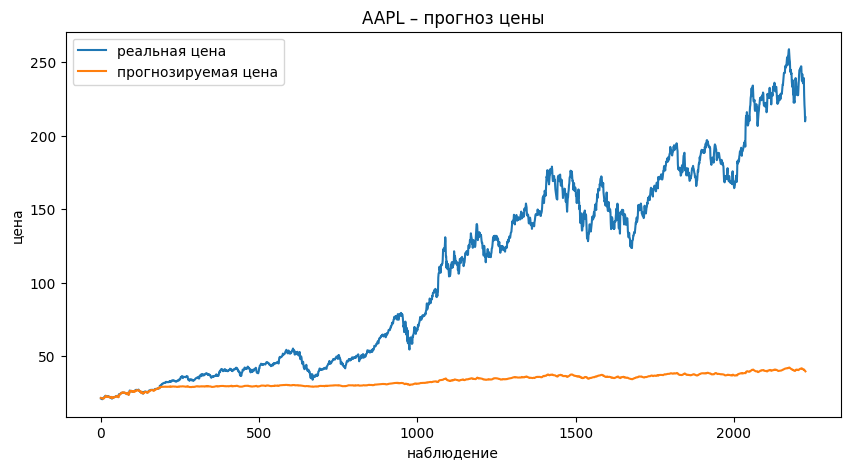

AutoML для доходности:
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Leaderboard (доходность):
                                            model_id      rmse       mse  \
0  StackedEnsemble_BestOfFamily_3_AutoML_2_202503...  0.029638  0.000878   
1  StackedEnsemble_BestOfFamily_1_AutoML_2_202503...  0.029638  0.000878   
2  StackedEnsemble_AllModels_1_AutoML_2_20250314_...  0.029640  0.000879   
3                     GLM_1_AutoML_2_20250314_175627  0.029647  0.000879   
4  StackedEnsemble_BestOfFamily_2_AutoML_2_202503...  0.029650  0.000879   

        mae     rmsle  mean_residual_deviance  
0  0.020619  0.030132                0.000878  
1  0.020615  0.030133                0.000878  
2  0.020623  0.030136                0.000879  
3  0.020628  0.030141                0.000879  
4  0.020625  0.030146                0.000879  
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


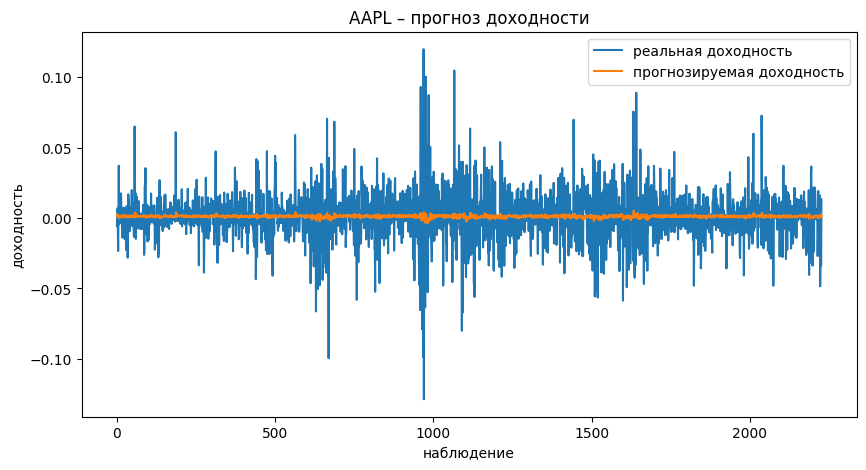

AutoML для цены:
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Leaderboard (цена):
                                            model_id      rmse       mse  \
0  StackedEnsemble_BestOfFamily_2_AutoML_3_202503...  0.232879  0.054233   
1  StackedEnsemble_BestOfFamily_3_AutoML_3_202503...  0.232935  0.054259   
2  StackedEnsemble_AllModels_2_AutoML_3_20250314_...  0.234351  0.054920   
3                     GBM_2_AutoML_3_20250314_175933  0.234433  0.054959   
4  StackedEnsemble_AllModels_1_AutoML_3_20250314_...  0.234465  0.054974   

        mae     rmsle  mean_residual_deviance  
0  0.110711  0.012796                0.054233  
1  0.110686  0.012770                0.054259  
2  0.111703  0.012875                0.054920  
3  0.108911  0.011186                0.054959  
4  0.111775  0.012877                0.054974  
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


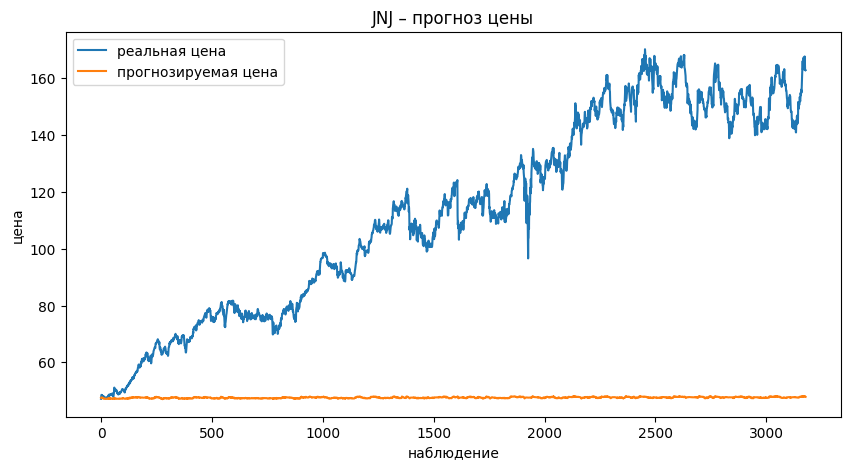

AutoML для доходности:
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Leaderboard (доходность):
                                            model_id      rmse       mse  \
0  StackedEnsemble_BestOfFamily_3_AutoML_4_202503...  0.015062  0.000227   
1  StackedEnsemble_BestOfFamily_1_AutoML_4_202503...  0.015068  0.000227   
2  StackedEnsemble_AllModels_3_AutoML_4_20250314_...  0.015072  0.000227   
3                     GLM_1_AutoML_4_20250314_180237  0.015076  0.000227   
4  StackedEnsemble_BestOfFamily_2_AutoML_4_202503...  0.015080  0.000227   

        mae     rmsle  mean_residual_deviance  
0  0.010753  0.015059                0.000227  
1  0.010753  0.015065                0.000227  
2  0.010756  0.015070                0.000227  
3  0.010752  0.015072                0.000227  
4  0.010753  0.015077                0.000227  
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


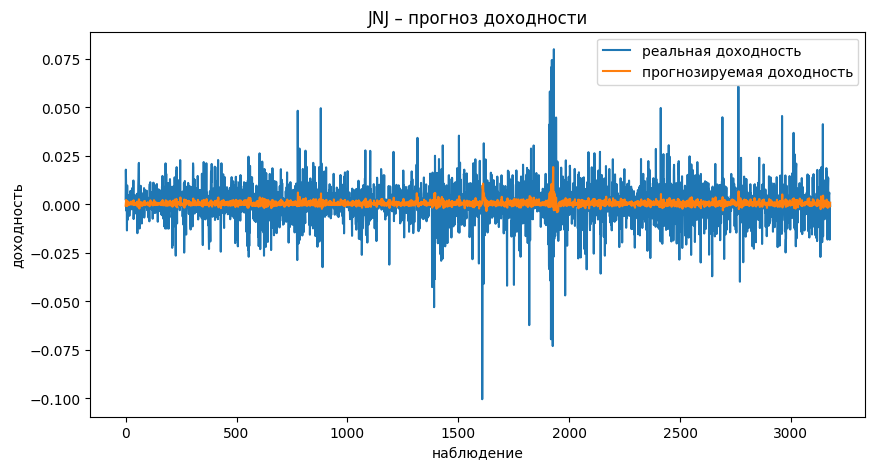

AutoML для цены:
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
Leaderboard (цена):
                                            model_id      rmse       mse  \
0  StackedEnsemble_AllModels_2_AutoML_5_20250314_...  0.300988  0.090594   
1  StackedEnsemble_AllModels_1_AutoML_5_20250314_...  0.301093  0.090657   
2  StackedEnsemble_BestOfFamily_3_AutoML_5_202503...  0.301400  0.090842   
3  StackedEnsemble_BestOfFamily_2_AutoML_5_202503...  0.301539  0.090926   
4  StackedEnsemble_BestOfFamily_1_AutoML_5_202503...  0.304409  0.092665   

        mae     rmsle  mean_residual_deviance  
0  0.125693  0.012846                0.090594  
1  0.125691  0.012858                0.090657  
2  0.126006  0.012791                0.090842  
3  0.126312  0.012853                0.090926  
4  0.129125  0.013726                0.092665  
Parse progress: |

/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


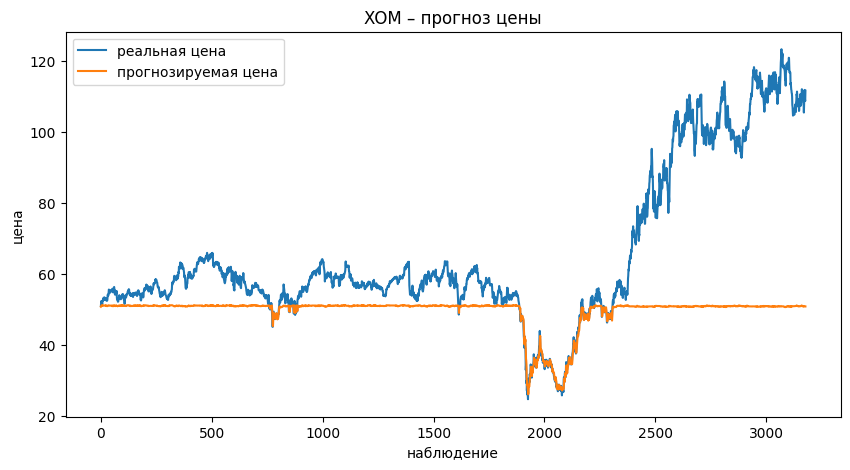

AutoML для доходности:
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
Leaderboard (доходность):
                                            model_id      rmse       mse  \
0  StackedEnsemble_BestOfFamily_2_AutoML_6_202503...  0.013887  0.000193   
1        GBM_grid_1_AutoML_6_20250314_180844_model_4  0.013892  0.000193   
2  StackedEnsemble_BestOfFamily_3_AutoML_6_202503...  0.013894  0.000193   
3  StackedEnsemble_BestOfFamily_4_AutoML_6_202503...  0.013896  0.000193   
4  StackedEnsemble_AllModels_1_AutoML_6_20250314_...  0.013897  0.000193   

        mae     rmsle  mean_residual_deviance  
0  0.009885  0.013922                0.000193  
1  0.009911  0.013920                0.000193  
2  0.009890  0.013928                0.000193  
3  0.009900  0.013930                0.000193  
4  0.009885  0.013930                0.000193  


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


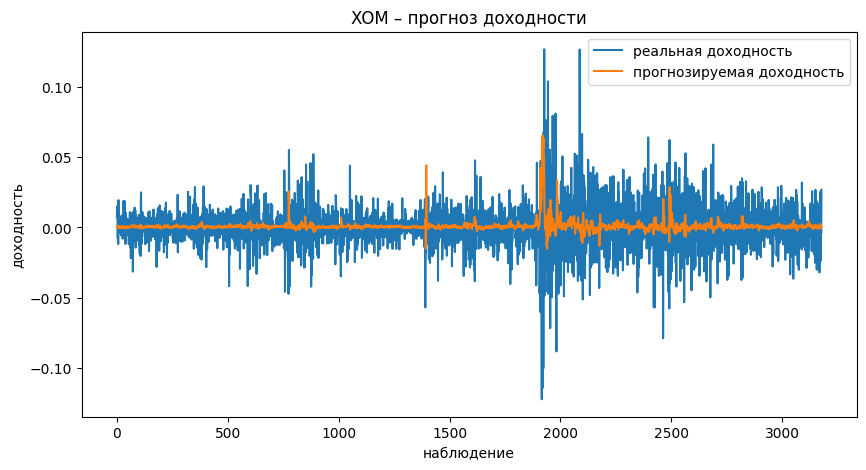

AutoML для цены:
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
Leaderboard (цена):
                                            model_id      rmse       mse  \
0  StackedEnsemble_BestOfFamily_3_AutoML_7_202503...  0.458053  0.209812   
1  StackedEnsemble_BestOfFamily_4_AutoML_7_202503...  0.458140  0.209892   
2  StackedEnsemble_BestOfFamily_2_AutoML_7_202503...  0.458185  0.209934   
3  StackedEnsemble_AllModels_1_AutoML_7_20250314_...  0.459324  0.210978   
4  StackedEnsemble_AllModels_3_AutoML_7_20250314_...  0.459433  0.211079   

        mae     rmsle  mean_residual_deviance  
0  0.254061  0.021683                0.209812  
1  0.254080  0.021682                0.209892  
2  0.254086  0.021678                0.209934  
3  0.255066  0.021722                0.210978  
4  0.255278  0.021759                0.211079  
Parse progress: |

/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


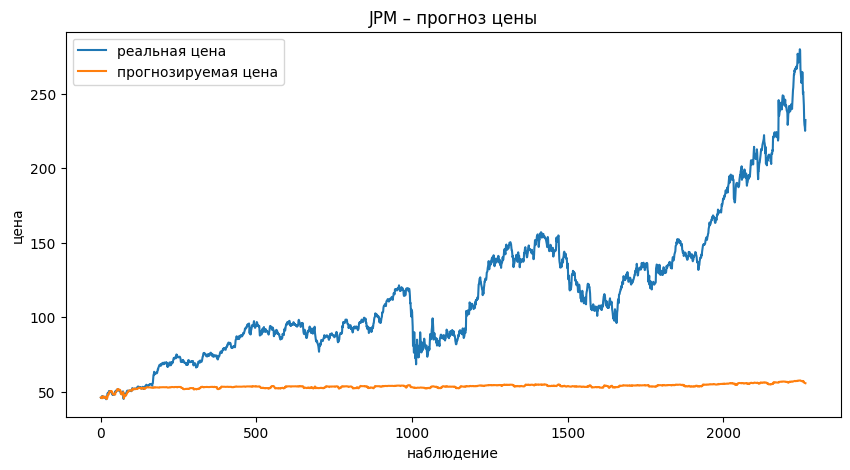

AutoML для доходности:
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Leaderboard (доходность):
                                            model_id      rmse       mse  \
0  StackedEnsemble_BestOfFamily_2_AutoML_8_202503...  0.023208  0.000539   
1  StackedEnsemble_BestOfFamily_3_AutoML_8_202503...  0.023217  0.000539   
2  StackedEnsemble_AllModels_2_AutoML_8_20250314_...  0.023219  0.000539   
3  StackedEnsemble_BestOfFamily_1_AutoML_8_202503...  0.023231  0.000540   
4        GBM_grid_1_AutoML_8_20250314_181451_model_2  0.023236  0.000540   

        mae     rmsle  mean_residual_deviance  
0  0.015409  0.023177                0.000539  
1  0.015414  0.023186                0.000539  
2  0.015418  0.023188                0.000539  
3  0.015408  0.023190                0.000540  
4  0.015477  0.023221                0.000540  
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


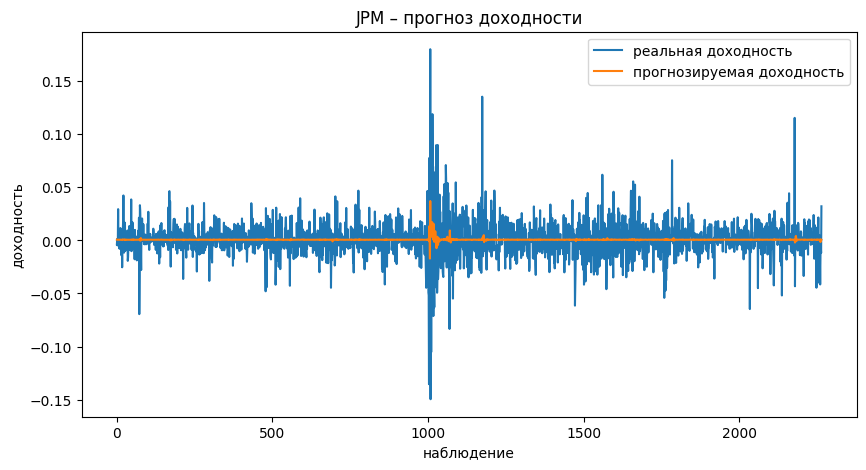

AutoML для цены:
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
Leaderboard (цена):
                                            model_id      rmse       mse  \
0  StackedEnsemble_AllModels_2_AutoML_9_20250314_...  0.125554  0.015764   
1  StackedEnsemble_AllModels_1_AutoML_9_20250314_...  0.125688  0.015797   
2  StackedEnsemble_BestOfFamily_2_AutoML_9_202503...  0.125984  0.015872   
3  StackedEnsemble_BestOfFamily_3_AutoML_9_202503...  0.126025  0.015882   
4                     GBM_2_AutoML_9_20250314_181757  0.126194  0.015925   

        mae     rmsle  mean_residual_deviance  
0  0.066002  0.012503                0.015764  
1  0.066012  0.012464                0.015797  
2  0.065848  0.012469                0.015872  
3  0.065846  0.012465                0.015882  
4  0.064754  0.011908                0.015925  
Parse progress: |

/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


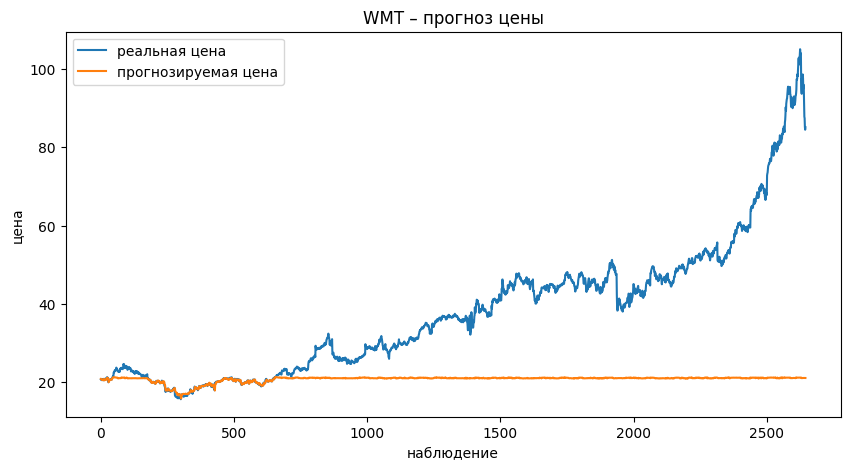

AutoML для доходности:
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
Leaderboard (доходность):
                                            model_id      rmse       mse  \
0  StackedEnsemble_AllModels_2_AutoML_10_20250314...  0.019428  0.000377   
1  StackedEnsemble_AllModels_3_AutoML_10_20250314...  0.019432  0.000378   
2                    GLM_1_AutoML_10_20250314_182100  0.019435  0.000378   
3  StackedEnsemble_BestOfFamily_1_AutoML_10_20250...  0.019436  0.000378   
4  StackedEnsemble_BestOfFamily_2_AutoML_10_20250...  0.019436  0.000378   

        mae     rmsle  mean_residual_deviance  
0  0.013652  0.019401                0.000377  
1  0.013656  0.019404                0.000378  
2  0.013664  0.019408                0.000378  
3  0.013650  0.019408                0.000378  
4  0.013653  0.019410                0.000378  
Parse progress: 

/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


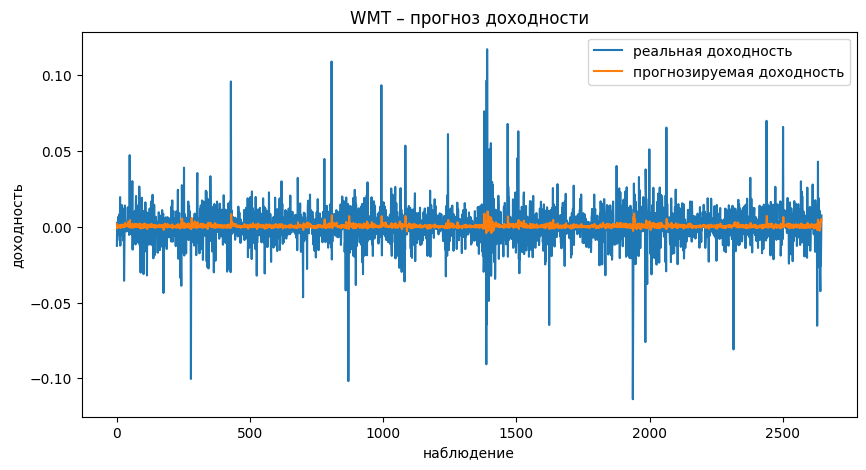

In [14]:
results_extended = {}

for ticker in tickers:
    results_extended[ticker] = {}

    # Задача 1: Прогноз цены
    print("AutoML для цены:")
    train_price = data_dict[ticker]['train_price']
    test_price = data_dict[ticker]['test_price']
    features_price = [col for col in train_price.columns if col not in ['target']]
    target_price = 'target'

    aml_price = run_automl(train_price, features_price, target_price, max_runtime_secs=180, seed=42)
    lb_price = aml_price.leaderboard.as_data_frame()
    print("Leaderboard (цена):")
    print(lb_price.head())
    results_extended[ticker]['price_lb'] = lb_price

    test_h2o_price = h2o.H2OFrame(test_price.reset_index(drop=True))
    preds_price = aml_price.leader.predict(test_h2o_price)
    preds_price_df = preds_price.as_data_frame()
    test_price_reset = test_price.reset_index(drop=True)

    plt.figure(figsize=(10,5))
    plt.plot(test_price_reset['target'].values, label='реальная цена')
    plt.plot(preds_price_df['predict'].values, label='прогнозируемая цена')
    plt.title(f'{ticker} – прогноз цены')
    plt.xlabel("наблюдение")
    plt.ylabel("цена")
    plt.legend()
    plt.show()

    # Задача 2: Прогноз доходности
    print("AutoML для доходности:")
    train_return = data_dict[ticker]['train_return']
    test_return = data_dict[ticker]['test_return']
    features_return = [col for col in train_return.columns if col not in ['target']]
    target_return = 'target'

    aml_return = run_automl(train_return, features_return, target_return, max_runtime_secs=180, seed=42)
    lb_return = aml_return.leaderboard.as_data_frame()
    print("Leaderboard (доходность):")
    print(lb_return.head())
    results_extended[ticker]['return_lb'] = lb_return

    test_h2o_return = h2o.H2OFrame(test_return.reset_index(drop=True))
    preds_return = aml_return.leader.predict(test_h2o_return)
    preds_return_df = preds_return.as_data_frame()
    test_return_reset = test_return.reset_index(drop=True)

    plt.figure(figsize=(10,5))
    plt.plot(test_return_reset['target'].values, label='реальная доходность')
    plt.plot(preds_return_df['predict'].values, label='прогнозируемая доходность')
    plt.title(f'{ticker} – прогноз доходности')
    plt.xlabel("наблюдение")
    plt.ylabel("доходность")
    plt.legend()
    plt.show()

In [16]:
ticker_example = 'AAPL'
results_extended[ticker_example]['price_lb'].head()

,model_id,rmse,mse,mae,rmsle,mean_residual_deviance
0,StackedEnsemble_BestOfFamily_2_AutoML_1_202503...,0.134771,0.018163,0.052705,0.012775,0.018163
1,StackedEnsemble_BestOfFamily_3_AutoML_1_202503...,0.134984,0.018221,0.052744,0.012770,0.018221
2,StackedEnsemble_AllModels_2_AutoML_1_20250314_...,0.135636,0.018397,0.052990,0.012831,0.018397
3,StackedEnsemble_AllModels_1_AutoML_1_20250314_...,0.135754,0.018429,0.053038,0.012830,0.018429
4,GBM_4_AutoML_1_20250314_175322,0.136304,0.018579,0.052491,0.012581,0.018579


In [17]:
results_extended[ticker_example]['return_lb'].head()

,model_id,rmse,mse,mae,rmsle,mean_residual_deviance
0,StackedEnsemble_BestOfFamily_3_AutoML_2_202503...,0.029638,0.000878,0.020619,0.030132,0.000878
1,StackedEnsemble_BestOfFamily_1_AutoML_2_202503...,0.029638,0.000878,0.020615,0.030133,0.000878
2,StackedEnsemble_AllModels_1_AutoML_2_20250314_...,0.029640,0.000879,0.020623,0.030136,0.000879
3,GLM_1_AutoML_2_20250314_175627,0.029647,0.000879,0.020628,0.030141,0.000879
4,StackedEnsemble_BestOfFamily_2_AutoML_2_202503...,0.029650,0.000879,0.020625,0.030146,0.000879
